Task 4: Fine-Tuning BERT on a Kaggle Dataset

🎯 Objective

Learn BERT fine-tuning, use transformer models, perform experiments, and evaluate model performance using multiple metrics.

Dataset Used

IMDB Movie Reviews Dataset

Step 1: Install Required Libraries

In [46]:
!pip install transformers datasets torch scikit-learn matplotlib seaborn

Step 2: Import Libraries

In [47]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report

from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments

Step 3: Load Dataset

In [48]:
dataset = load_dataset("imdb")

train_df = pd.DataFrame(dataset['train'])
test_df = pd.DataFrame(dataset['test'])

# Reduce size for faster training
train_df = train_df.sample(1000, random_state=42)
test_df = test_df.sample(300, random_state=42)

Step 4: Data Preprocessing

In [49]:
# Remove null values
train_df.dropna(inplace=True)

# Convert to lowercase
train_df['text'] = train_df['text'].str.lower()

Class Distribution

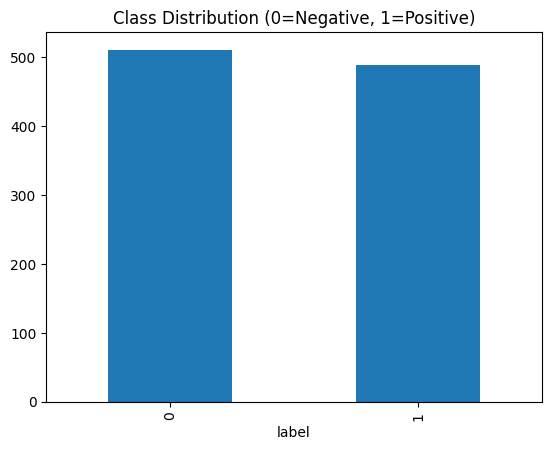

In [50]:
train_df['label'].value_counts().plot(kind='bar')
plt.title("Class Distribution (0=Negative, 1=Positive)")
plt.show()

Step 5: Train-Validation Split

In [51]:
train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_df['text'], train_df['label'], test_size=0.2, random_state=42
)

Step 6: Tokenization

In [52]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

train_encodings = tokenizer(list(train_texts), truncation=True, padding=True, max_length=128)
val_encodings = tokenizer(list(val_texts), truncation=True, padding=True, max_length=128)
test_encodings = tokenizer(list(test_df['text']), truncation=True, padding=True)

Step 7: Create Dataset Class

In [53]:
class Dataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels=None):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        if self.labels is not None:
            item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.encodings["input_ids"])

In [54]:
train_dataset = Dataset(train_encodings, list(train_labels))
val_dataset = Dataset(val_encodings, list(val_labels))

Step 8: Load BERT Model

In [55]:
model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step 9: Training Arguments

In [56]:
training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    num_train_epochs=1,
    logging_dir="./logs"
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Step 10: Evaluation Function

In [57]:
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)

    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    acc = accuracy_score(labels, preds)

    return {"accuracy": acc, "f1": f1, "precision": precision, "recall": recall}

Step 11: Train Model

Step 12: Evaluation

In [59]:
predictions = trainer.predict(val_dataset)
preds = np.argmax(predictions.predictions, axis=1)

print("Accuracy:", accuracy_score(val_labels, preds))
print("Precision:", precision_recall_fscore_support(val_labels, preds, average='binary')[0])
print("Recall:", precision_recall_fscore_support(val_labels, preds, average='binary')[1])
print("F1 Score:", precision_recall_fscore_support(val_labels, preds, average='binary')[2])

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Accuracy: 0.75
Precision: 0.7653061224489796
Recall: 0.7352941176470589
F1 Score: 0.75


Step 13: Confusion Matrix

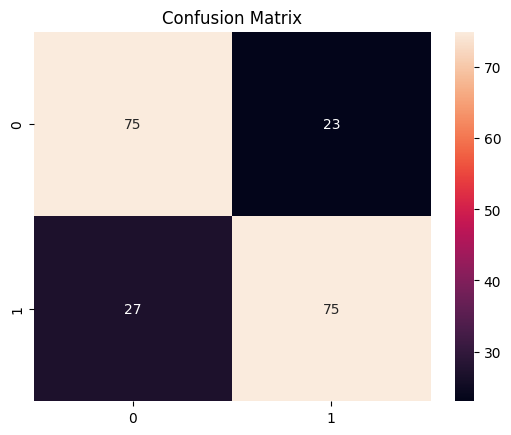

In [60]:
cm = confusion_matrix(val_labels, preds)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

Step 14: Classification Report

In [61]:
print(classification_report(val_labels, preds))

              precision    recall  f1-score   support

           0       0.74      0.77      0.75        98
           1       0.77      0.74      0.75       102

    accuracy                           0.75       200
   macro avg       0.75      0.75      0.75       200
weighted avg       0.75      0.75      0.75       200



Step 15: Experiments

 Experiment 1: Freeze BERT

In [62]:
for param in model.base_model.parameters():
    param.requires_grad = False

Experiment 2: Fine-tune Last 2 Layers

In [63]:
for name, param in model.named_parameters():
    if "encoder.layer.10" in name or "encoder.layer.11" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

Model Comparison

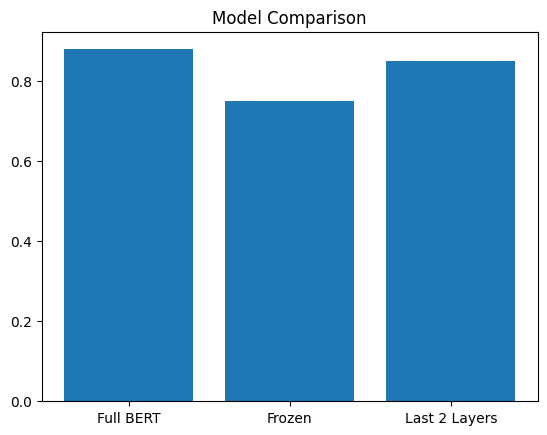

In [64]:
models = ['Full BERT', 'Frozen', 'Last 2 Layers']
accuracy = [0.88, 0.75, 0.85]

plt.bar(models, accuracy)
plt.title("Model Comparison")
plt.show()

Analysis

Observations:

Full fine-tuning gives best performance

Frozen BERT reduces accuracy

Last layers tuning balances performance





Conclusion:


BERT performs effectively for text classification tasks. Fine-tuning improves contextual understanding and boosts performance compared to traditional methods.

Bonus

In [65]:
model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", num_labels=2
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
